<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Astronomia-de-posicion/Parcial2_AstroPos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANÁLISIS &nbsp;DEL &nbsp;MOVIMIENTO &nbsp;DE &nbsp;MARTE**
<br>

### &nbsp; **Astronomía de Posición:** &nbsp;&nbsp;Parcial $2$ - Parte practica

>  &nbsp; &nbsp; *Juan Manuel Cárdenas*





<br>

___


In [ ]:
# Librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime
from google.colab import files
from astropy.time import Time
from scipy.signal import argrelextrema
from tqdm import tqdm
%matplotlib inline

In [ ]:
# Parametros Importantes:
rad = np.pi/180          # grados a rads
hor = (360/24)*np.pi/180 # horas a rads
e   = 23.5*rad           # oblicuidad tierra
i_m = 1.850              # inclinacion orbita marte respecto ecliptica
ra_pg  = 192.85*rad      # RA polo norte galactico
dec_pg = 27.33*rad       # DEC polo norte galactico
l_N    = 123*rad         # long galactic polo norte galactico
t_tierra = 365.25        # periodo sideral tierra [dias]

# **PUNTO 1)**
###**(A) Subida, Lectura de Datos y Cambio de Formato**

<p align="justify"> En el archivo subido se encuentran los datos de $Declinación$ ($°$ $'$ $"$), $Ascensión$ $recta$ (HH MM SS), y su respectiva fecha de observación (UT_date HH:MM) para el planeta Marte. El formado de $RA$ y $DEC$ estrictamente es $ICRF$, que a su vez tiene como sistema de referencia
el $ICRS$, que son aproximadamente iguales a las coordenadas Ecuatoriales Absolutas.  </p>



In [ ]:
# subir datos (nombre: mars.csv)
fil = files.upload()

Saving mars.csv to mars.csv


In [ ]:
# Leer datos con pandas (de nombre mars.csv)
datos = pd.read_csv('mars.csv', sep=',') # datos separados por ','

# columnas de datos como arrays: tiempo universal; Asencion recta; Declinacion
UT = np.array(datos[' Date__(UT)__HR:MN']) # año mes dia horas=0
RA = np.array(datos[' R.A._(ICRF)'])       # horas min seg
DEC= np.array(datos[' DEC__(ICRF)'])       # grados min seg

# datos.keys() # verifica los nombres de cada columna (todos tienen un espacio primero, lo cual causaba problemas al no agregarlo)

<p align="justify"> Los datos de cada columna están en formato String, luego hay que hacer un split para separarlos, hacer la transformación respectiva a una única unidad (días, horas, o grados) para poder tratar cada valor.
Por lo tanto, se deben crear funciones para realizar esta conversión. Además, note que cada valor tiene un espacio vacío al inicio, luego al hacer el split saldrán 4 valores, pero el primero será un espacio vacío que no se deberá tener en cuenta.</p>

1.   Tiempo Universal: ` input: UT[0] output:  '  2018-Jan-01 00:00' `
2.   Ascensión recta: ` input: RA[0] output:  ' 14 46 58.07' `
3.   Declinación: ` input: DEC[0] output:  '  -15 09 25.8' `
<br>

<p align="justify"> Hay que tener cuidado en las conversiones, pues si hay valores negativos no se sumaran adecuadamente, luego hay que poner un condicional para los valores negativos, caso que solo ocurre en la Declinación, pues sus valores están en el rango: $[-90°,90°]$. Mientras el rango de Ascensión recta está en $[0h,24h]$.
Note que el signo ($±$) está en el primer número de DEC, que son los grados, luego basta poner el condicional allí.

Los valores de UT se encuentran separados por espacios vacíos ( ) y por guiones ( - ), por lo que se debe realizar un doble split. </p><br>

#### **Funciones de Conversión:**


In [ ]:
def HMS_2_H(time_str):   # Transforma: (HH MM SS) a (HH)                         [para RA] ----------------------------------
    void, h, m, s = time_str.split(' ') # cuidado, existe valor vacio al inicio
    return float(h) + float(m)/60 + float(s)/3600

def GMS_2_G(grade_str):  # Transforma: (° ' ") a (°)                             [para DEC] ---------------------------------
    void, g, m, s = grade_str.split(' ')
    if grade_str[1]=='-' : # condicion(-), el ± se encuentra en posicion 1
      return -(np.abs(float(g)) + float(m)/60 + float(s)/3600)
    else: return float(g) + float(m)/60 + float(s)/3600

def YMD_corr(year_str): # Corrige(YYYY MM DD)                                    [para UT] forma 1 --------------------------
    void, date, hour = year_str.split(' ')
    y, m, d = date.split('-')
    m = datetime.datetime.strptime(m, "%b").month # pasa mes a numero
    return str(y+'-'+str(m)+'-'+d+' '+hour)

def YMD_2_JD(year_str):  # Transforma: (YYYY MM DD) a (JD)                       [para UT] forma 2 --------------------------
    void, date, hour = year_str.split(' ')
    y, m, d = date.split('-')
    m = datetime.datetime.strptime(m, "%b").month # pasa mes a numero
    JD = Time( str(y+'-'+str(m)+'-'+d) ).jd       # (yyyy mm dd) a (jd)
    return JD

In [ ]:
# Aplicando las conversiones a cada valor de las listas
ra_h  = np.zeros(len(RA)) # arreglos y lista vacios
dec_g = np.zeros(len(DEC))
ut_jd = np.zeros(len(UT))
ut_corr = []

for i in range(len(RA)):
  ra_h[i]  = HMS_2_H(RA[i])       # RA en horas
  dec_g[i] = GMS_2_G(DEC[i])      # DEC en grados
  ut_jd[i] = YMD_2_JD(UT[i])      # UT en dias julianos
  ut_corr.append(YMD_corr(UT[i])) # UT a evaluar en datetime

ut_date = pd.to_datetime(ut_corr) # UT en datetime

### **(B) Graficacion Coords Ecuatoriales de Marte**

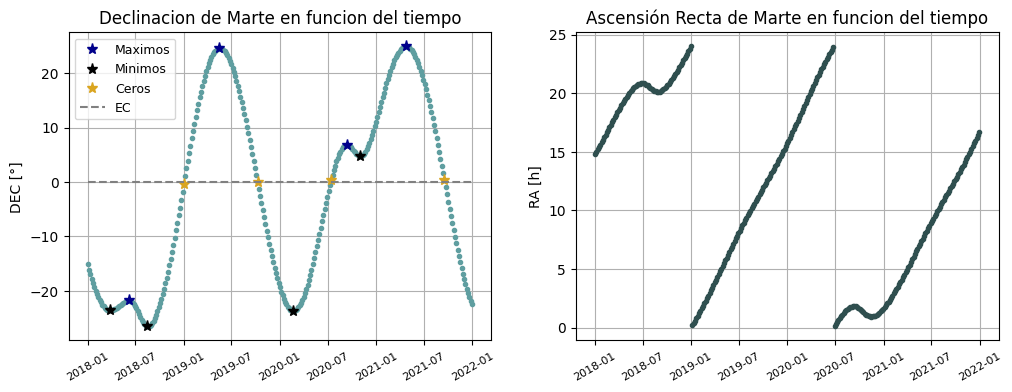

In [ ]:
# Extremos de DEC (d.1 siguiente celda)
ind_max_dec = argrelextrema( dec_g, np.greater)[0] # indice DEC max
dec_max     = dec_g[ ind_max_dec ]                 # valores maximos DEC
ut_max_dec  = ut_date[ ind_max_dec ]               # tiempos asociados a dec_max
ind_min_dec = argrelextrema( dec_g, np.less)[0]    # index DEC min
dec_min     = dec_g[ ind_min_dec ]                 # valores minimos DEC
ut_min_dec  = ut_date[ ind_min_dec ]               # tiempos asociados a dec_min

# Ceros de DEC
cero_dec = dec_g[ (dec_g < .5) & (dec_g > -.5) ]   # boolean mask para ceros aproximados
ind_0_dec = []
for i in range(len(cero_dec)):
  ind_0_dec.append(np.where(dec_g == cero_dec[i])[0][0] ) # indices de ceros
ut_0_dec  = ut_date[ ind_0_dec]

# Grafica
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

axes[0].plot( ut_date, dec_g,'.', color='#5F9EA0')   # DEC
axes[0].plot( ut_max_dec, dec_max,'*',color='darkblue',markersize=8,label='Maximos') # max DEC
axes[0].plot( ut_min_dec, dec_min,'*',color='k',markersize=8, label='Minimos')       # min DEC
axes[0].plot( ut_0_dec, cero_dec,'*',color='#DAA520',markersize=8, label='Ceros')    # ceros DEC
axes[0].hlines(0,ut_date[0],ut_date[-1],'gray','--', label='EC')
axes[0].set_title('Declinacion de Marte en funcion del tiempo')
axes[0].set_ylabel('DEC [°]')
axes[0].tick_params(axis='x', labelrotation = 30, labelsize=8)
axes[0].legend(fontsize="9")
axes[0].grid()

axes[1].plot( ut_date, ra_h,'.', color='#2F4F4F')    # RA
axes[1].set_title('Ascensión Recta de Marte en funcion del tiempo')
axes[1].set_ylabel('RA [h]')
axes[1].tick_params(axis='x', labelrotation = 30, labelsize=8)
axes[1].grid()
plt.show()

####**D.1)** Máximos, Mínimos (Globales y Locales) Y Ceros en Declinación <br>

Para encontrar los máximos y mínimos en general se hizo uso de la función `argrelextrema` de la librería ` scipy.signal ` con argumento np.greater y np.less respectivamente. Mientras que para los puntos de cruce con el respectivo plano se creó una máscara booleana con un intervalo particular cercano a cero para que aislara el valor más cercano a cero para cada grupo de datos.

In [ ]:
# Extremos
print('Todos los maximos locales de Declinacion [°]:', dec_max) # los locales incluyen a los globales
print('Timepos asociados a los maximos locales:', ut_max_dec)
print('\nTodos los minimos locales de Declinacion [°]:', dec_min)
print('Timepos asociados a los maximos locales:', ut_min_dec)
# Ceros
print('\nDeclinacion de puntos de cruce con el Ecuador Celeste [°]:',cero_dec)
print('Timepos asociados a los puntos de cruce [°]:', ut_0_dec)
# Extremos Globales
print('\nMaximo Global de Declinacion[°]:', max(dec_g))
print('Minimo Global de Declinacion[°]:', min(dec_g))

Todos los maximos locales de Declinacion [°]: [-21.76533333  24.55866667   6.75641667  24.89311111]
Timepos asociados a los maximos locales: DatetimeIndex(['2018-06-05', '2019-05-16', '2020-09-12', '2021-04-25'], dtype='datetime64[ns]', freq=None)

Todos los minimos locales de Declinacion [°]: [-23.56386111 -26.54080556 -23.67394444   4.70980556]
Timepos asociados a los maximos locales: DatetimeIndex(['2018-03-27', '2018-08-14', '2020-02-20', '2020-11-01'], dtype='datetime64[ns]', freq=None)

Declinacion de puntos de cruce con el Ecuador Celeste [°]: [-0.40313889  0.00055556  0.37486111  0.34255556]
Timepos asociados a los puntos de cruce [°]: DatetimeIndex(['2019-01-01', '2019-10-08', '2020-07-14', '2021-09-17'], dtype='datetime64[ns]', freq=None)

Maximo Global de Declinacion[°]: 24.89311111111111
Minimo Global de Declinacion[°]: -26.540805555555558


####**Discusión:**
<p align="justify"> Debido a que la órbita de marte tiene una inclinación angular de $i_m=1.850°$ respecto a la eclíptica$^{[1]}$, y como la Eclíptica se encuentra inclinada $\epsilon≈23.5°$ con respecto al Ecuador Celeste. Entonces se podría suponer que el ángulo máximo y mínimo entre marte y el EC es: $δ_m=\epsilon±i_m =$ ($21.65°$ y $25.35°$ en magnitud). Entonces la $Declinación$ de marte respecto tiempo tendría la forma de una función periódica (pues por su definición: ángulo entre el astro y el EC, medido sobre el circulo de declinación del astro) $DEC$ tomaría valores limitados por la cota debida a la órbita cerrada y la inclinación anteriormente calculada, además, pasando por $DEC$=$0°$ dos veces por cada revolución del planeta, haciendo a la función cíclica. </p>

**Inclinación de la Órbita y Excentricidad:**
<p align="center">
<img src=https://i.postimg.cc/5jdYtT2N/oblicuidad-orbit.png width="400">
<br>
<font size=2>Fig1. COSMOS-The SAO Encyclopedia of Astronomy. Orbital Inclination.</font></p>


<p align="justify"> De la gráfica obtenida para $DEC$ se puede observar que si sigue una tendencia de función periódica como se esperaba, sin embargo, se evidencian dos secciones donde toma el siguiente comportamiento: "se detiene momentáneamente, retrocede, y vuelve a detenerse para finalmente seguir con la trayectoria inicial"; Análogo, y posiblemente explicado por el movimiento de retrogradación de Marte; en el cual la tierra y marte se encuentran en oposición.
Note también que el máximo y mínimo global de los datos $DEC$  ($24.89°$ y $-26.54°$ respectivamente) no corresponden exactamente con la magnitud de los valores supuestos en el párrafo anterior, lo cual puede deberse a que la no despreciable excentricidad de Marte puede causar un leve "desplazamiento" del rango de este ángulo, como se observa en la figura 1.</p>

<p align="justify"> Por su parte para la $Ascensión$ $Recta$, lo primero a mencionar es que los cortes de la función (a trozos) son esperados, pues como se mencionó anteriormente, está en el rango $[0h,24h]$ por lo que cuando $RA$ pasa de $24h$ el planeta ha dado una revolución al punto vernal, y $RA$ se reinicia al valor $0$. A primera vista la $RA$ parece tener un crecimiento lineal a medida que el tiempo aumenta, excepto en un par de secciones donde se produce el mismo comportamiento mencionado debido al movimiento retrogrado del planeta rojo, en las mismas fechas en las que ocurre tal movimiento en la declinación. </p>


**Bibliografía:**
<font size=2>
1.   Georgia State Univerity (2017). Hyper physics Solar System Data; Mars Data. Recuperado de: http://hyperphysics.phy-astr.gsu.edu/hbasees/Solar/soldata2.html  </font></p>

<br>

### **(C) Transformación a Coordenadas Eclípticas y Galácticas**
Empleando las ecuaciones del libro Elementos de Astronomía y las de transformación vistas en clase, se construyen las siguientes funciones:

In [ ]:
def ecu_2_eclip(ra,dec):  # de Ecuatoriales a eclipticas
  β = np.arcsin( np.sin(dec)*np.cos(e) - np.cos(dec)*np.sin(e)*np.sin(ra)  )
  p = np.sin(dec)*np.sin(e) + np.cos(dec)*np.cos(e)*np.sin(ra) # numerador
  q = np.cos(ra)*np.cos(dec)                                   # denominador
  λ = np.arctan( p/q )

  if p*q<0 and q<0:   λ = λ + np.pi        # condiciones de cuadrante
  elif p*q<0 and q>0: λ = λ + 2*np.pi
  elif p+q <0:        λ = λ + np.pi
  return β,λ

def ecu_2_galact(ra,dec): # de Ecuatoriales a Galacticas
  b = np.arcsin( np.sin(dec_pg)*np.sin(dec) + np.cos(dec_pg)*np.cos(dec)*np.cos(ra-ra_pg)  )
  p = np.cos(dec)*np.sin(ra-ra_pg)                                              # numerador
  q = np.sin(dec)*np.cos(dec_pg) - np.cos(dec)*np.sin(dec_pg)*np.cos(ra-ra_pg)  # denominador
  atang = np.arctan( p/q )

  if p*q<0 and q<0:   atang= atang + np.pi # condiciones de cuadrante
  elif p*q<0 and q>0: atang= atang + 2*np.pi
  elif p+q <0:        atang= atang + np.pi

  l = l_N - atang

  if l<0:       l = l + 2*np.pi            # condiciones de rango
  if l>2*np.pi: l = l - 2*np.pi
  return b,l

# ------------------------------------------------------------------------------
# Aplicando la transformacion de coordenadas a los datos:

λ = np.zeros(len(ra_h)) ; β = np.zeros(len(ra_h)) # Arreglos vacios para cada coordenada
l = np.zeros(len(ra_h)) ; b = np.zeros(len(ra_h)) # (todos tienen mismo tamaño)

for i in range(len(ra_h)):
  β[i], λ[i] = ecu_2_eclip(  ra_h[i]*hor, dec_g[i]*rad ) # horas y grados a rad
  b[i], l[i] = ecu_2_galact( ra_h[i]*hor, dec_g[i]*rad ) # horas y grados a rad

β = β/rad ; λ = λ/rad  # Eclipticas (volviendo a grados para graficar)
b = b/rad ; l = l/rad  # Galacticas

### **Graficacion Coords Eclipticas de Marte**

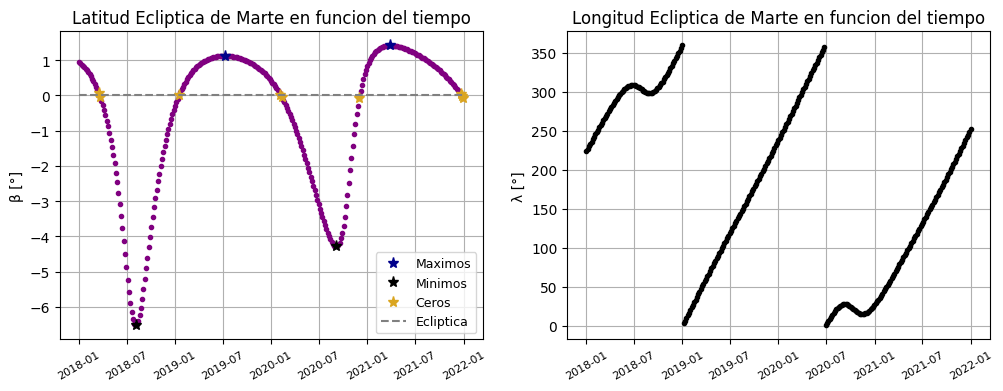

In [ ]:
# Extremos de β (d.2 siguiente celda)
ind_max_β = argrelextrema(  β, np.greater)[0] # indice  β max
β_max     = β[ ind_max_β ]                    # valores maximos  β
ut_max_β  = ut_date[ ind_max_β ]              # tiempos asociados a  β_max
ind_min_β = argrelextrema(  β, np.less)[0]    # index  β min
β_min     = β[ ind_min_β ]                    # valores minimos  β
ut_min_β  = ut_date[ ind_min_β ]              # tiempos asociados a  β_min

# Ceros de  β
cero_β =  β[ ( β < .08) & ( β > -.08) ]       # boolean mask para ceros aprox
ind_0_β = []
for i in range(len(cero_β)):
  ind_0_β.append(np.where(β == cero_β[i])[0][0] ) # indices de ceros
ut_0_β  = ut_date[ ind_0_β]

# Grafica coords Eclipticas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
axes[0].plot( ut_date, β,'.', color='purple')  # β: lat ecliptica
axes[0].plot( ut_max_β, β_max,'*',color='darkblue',markersize=8,label='Maximos') # max β
axes[0].plot( ut_min_β, β_min,'*',color='k',markersize=8, label='Minimos')       # min β
axes[0].plot( ut_0_β, cero_β,'*',color='#DAA520',markersize=8, label='Ceros')    # ceros β
axes[0].hlines(0,ut_date[0],ut_date[-1],'gray','--',label='Ecliptica')
axes[0].set_title('Latitud Ecliptica de Marte en funcion del tiempo')
axes[0].set_ylabel('β [°]')
axes[0].tick_params(axis='x', labelrotation = 30, labelsize=8)
axes[0].legend(fontsize="9")
axes[0].grid()

axes[1].plot( ut_date, λ,'.',color='k')   # λ: long ecliptica
axes[1].set_title('Longitud Ecliptica de Marte en funcion del tiempo')
axes[1].set_ylabel('λ [°]')
axes[1].tick_params(axis='x', labelrotation = 30, labelsize=8)
axes[1].grid()
plt.show()

####**D.2)** Máximos, Mínimos (Globales y Locales) y Ceros en Latitud Eclíptica

En este caso los puntos cercanos al 4 cero de latitud eclíptica se encontraban más espaciados que para los otros ceros, por lo que se debió tomar un intervalo más amplio para poder obtenerlos todos, lo que causo que se incluyeran algunos valores cercanos en los demás ceros.


In [ ]:
# Extremos
print('Todos los maximos locales de β [°]:', β_max)
print('Timepos asociados a los maximos locales:', ut_max_β)
print('\nTodos los minimos locales de β [°]:', β_min)
print('Timepos asociados a los minimos locales:', ut_min_β)
# Ceros
print('\nβ de puntos de cruce con la Ecliptica [°]:',cero_β)
print('Timepos asociados a los puntos de cruce [°]:', ut_0_β)
# Extremos Globales
print('\nMaximo Global de β[°]:', max(β))
print('Minimo Global de β[°]:', min(β))

Todos los maximos locales de β [°]: [1.12509026 1.42061436]
Timepos asociados a los maximos locales: DatetimeIndex(['2019-07-10', '2021-03-26'], dtype='datetime64[ns]', freq=None)

Todos los minimos locales de β [°]: [-6.52870188 -4.28719119]
Timepos asociados a los minimos locales: DatetimeIndex(['2018-08-04', '2020-09-02'], dtype='datetime64[ns]', freq=None)

β de puntos de cruce con la Ecliptica [°]: [ 0.05892935 -0.04614417  0.00434983  0.02027063 -0.04719853 -0.06616536
  0.04418681 -0.00745901 -0.06045191]
Timepos asociados a los puntos de cruce [°]: DatetimeIndex(['2018-03-17', '2018-03-22', '2019-01-16', '2020-02-05',
               '2020-02-10', '2020-12-01', '2021-12-21', '2021-12-26',
               '2021-12-31'],
              dtype='datetime64[ns]', freq=None)

Maximo Global de β[°]: 1.4206143566408063
Minimo Global de β[°]: -6.528701883553842


####**Discusión:**
<p align="justify"> En este caso, a diferencia de las Ecuatoriales, el Angulo de $latitud$ $Eclíptica$ se mide a partir de la Eclíptica, y como la órbita de marte está inclinada $i_m=1.850°$ con respecto a esta, entonces como primera aproximación se pensó que el rango de este ángulo estaría en $[-1.850°,1.850°]$. Sin embargo, los datos muestran un rango distinto y variable, como se muestra en la gráfica (siendo el primero: $[1.125°,-6.529°]$), que se hipotetiza puede deberse a 1: la excentricidad de la órbita de Marte, 2: a que este ángulo de latitud, que viene de las transformaciones de coordenadas Ecuatoriales que dependen del Ecuador terrestre, lo que causaría indirectamente que estos nuevos ángulos dependieran de la posición relativa Tierra-Marte-punto vernal. así, la variación de alguno de los tres conduciría a un cambio en el rango de latitud eclíptica por paralaje. Lo que explicaría el cambio en la magnitud de los mínimos siendo en el primer mínimo en el cual la tierra está en oposición con Marte, y más "cerca" al punto vernal, mientras en el segundo se da en otro punto más "lejano" del punto vernal, formándose así un ángulo distinto con el punto vernal.</p>

<p align="justify"> Note que en la latitud Eclíptica, si los puntos se encuentran más espaciados entre sí, quiere decir que en estas regiones marte tuvo un desplazamiento más "rápido" (hay menos datos por cantidad de tiempo), comparado con las regiones donde los puntos se encuentran más próximos entre sí. Dichas regiones donde el planeta parece haberse desplazado más rápido, coinciden con las fechas en las que se encontró en retrogradación (graficas ecuatoriales), y por tanto en oposición con la tierra. Una posible explicación sería que como el ángulo β depende indirectamente de la posición relativa Marte-Tierra, y en apariencia, un objeto se mueve más rápido a medida que se encuentre más cerca de su observador, entonces en la región de puntos más separados (donde marte tiene mayor "velocidad" aparente) marte estaría en el punto más cercano a su observador, la tierra, momento que se da en oposición, y por tanto en retrogradación. </p>

Se observa cualitativamente (más adelante se verá cuantitativamente en el punto 3-H) que la primer región de oposición (retrogradación) cubre un periodo de tiempo relativamente más grande que la segunda (la primer región de puntos separados cubre más tiempo que la segunda) es decir que Marte tuvo una mayor velocidad sobre su órbita en la segunda región, lo que se explica si en esta región Marte estuvo en, o más cerca de su perihelio que en la primera región, es decir que en la primera oposición, marte estaría más próximo de su afelio) pues por las leyes de Kepler sabemos que la velocidad de un cuerpo es mayor mientras más cerca está de su perihelio.


<p align="justify"> Para la $longitud$ $Eclíptica$ ocurre algo muy similar que con la Ascensión recta descrita en el punto anterior. crecimiento casi lineal con excepción de las zonas de retrogradación ocurridas en las mismas fechas. </p><br>


### **Graficacion Coords Galacticas de Marte**

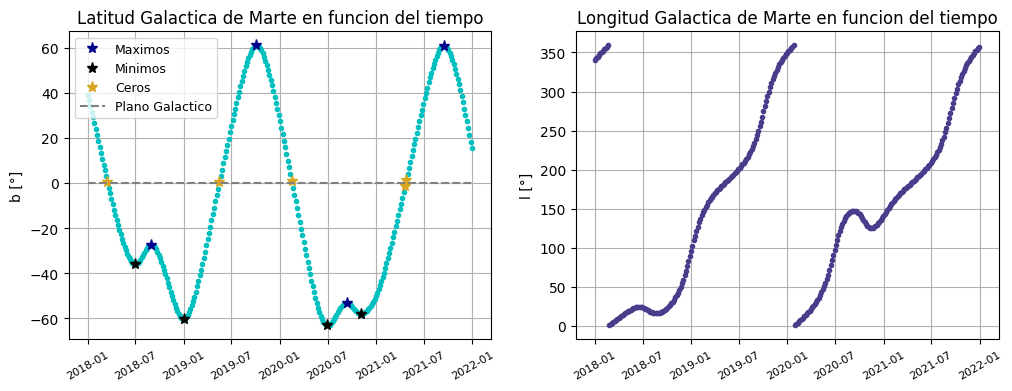

In [ ]:
# Extremos de b (d.3 siguiente celda)
ind_max_b = argrelextrema(  b, np.greater)[0] # indice  b max
b_max     =  b[ ind_max_b ]                   # valores maximos  b
ut_max_b  = ut_date[ ind_max_b ]              # tiempos asociados a  b_max
ind_min_b = argrelextrema(  b, np.less)[0]    # index  b min
b_min     =  b[ ind_min_b ]                   # valores minimos  b
ut_min_b  = ut_date[ ind_min_b ]              # tiempos asociados a  b_min

# Ceros de  b
cero_b =  b[ ( b < 2) & ( b > -2) ]           # boolean mask para ceros aprox
ind_0_b = []
for i in range(len(cero_b)):
  ind_0_b.append(np.where(b == cero_b[i])[0][0] ) # indices de ceros
ut_0_b  = ut_date[ ind_0_b]

# Grafica coords Galacticas
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
axes[0].plot( ut_date, b,'.', color='c')   # b: lat Galactica
axes[0].plot( ut_max_b, b_max,'*',color='darkblue',markersize=8,label='Maximos') # max b
axes[0].plot( ut_min_b, b_min,'*',color='k',markersize=8, label='Minimos')       # min b
axes[0].plot( ut_0_b, cero_b,'*',color='#DAA520',markersize=8, label='Ceros')    # ceros b
axes[0].hlines(0,ut_date[0],ut_date[-1],'gray','--',label='Plano Galactico')
axes[0].set_title('Latitud Galactica de Marte en funcion del tiempo')
axes[0].set_ylabel('b [°]')
axes[0].tick_params(axis='x', labelrotation = 30, labelsize=8)
axes[0].legend(fontsize="9")
axes[0].grid()

axes[1].plot( ut_date, l,'.',color='#483D8B') # l: long Galactica
axes[1].set_title('Longitud Galactica de Marte en funcion del tiempo')
axes[1].set_ylabel('l [°]')
axes[1].tick_params(axis='x', labelrotation = 30, labelsize=8)
axes[1].grid()
plt.show()

####**D.3)** Máximos, Mínimos (Globales y Locales) y Ceros en Latitud Galáctica

In [ ]:
# Extremos
print('Todos los maximos locales de b [°]:', b_max)
print('Timepos asociados a los maximos locales:', ut_max_b)
print('\nTodos los minimos locales de b [°]:', b_min)
print('Timepos asociados a los minimos locales:', ut_min_b)
# Ceros
print('\nb de puntos de cruce con el Plano Galactico [°]:',cero_b)
print('Timepos asociados a los puntos de cruce [°]:', ut_0_b)
# Extremos Globales
print('\nMaximo Global de b[°]:', max(b))
print('Minimo Global de b[°]:', min(b))

Todos los maximos locales de b [°]: [-27.46767656  60.97130515 -53.13735724  60.79775158]
Timepos asociados a los maximos locales: DatetimeIndex(['2018-08-29', '2019-10-03', '2020-09-12', '2021-09-17'], dtype='datetime64[ns]', freq=None)

Todos los minimos locales de b [°]: [-35.86221898 -60.30933613 -63.09290451 -57.86550203]
Timepos asociados a los minimos locales: DatetimeIndex(['2018-06-30', '2019-01-01', '2020-06-29', '2020-11-06'], dtype='datetime64[ns]', freq=None)

b de puntos de cruce con el Plano Galactico [°]: [ 0.48379788  0.33751531  0.95186861 -1.27357096  1.34569132]
Timepos asociados a los puntos de cruce [°]: DatetimeIndex(['2018-03-17', '2019-05-16', '2020-02-15', '2021-04-20',
               '2021-04-25'],
              dtype='datetime64[ns]', freq=None)

Maximo Global de b[°]: 60.97130514616381
Minimo Global de b[°]: -63.09290450633492


####**Discusión:**
<p align="justify"> El plano galáctico está inclinado un ángulo de 63° respecto al Ecuador Celeste, y 60° respecto a la Eclíptica$[1]$, por lo que se podría suponer en primera instancia, con el hecho de que orbita de marte está inclinada cerca de 1.85° con la eclíptica, que el rango de $latitud$ $galáctica$ estará acotado en magnitud por aproximadamente 61.85° valor muy cercano a los máximos y mínimos globales obtenidos, a pesar de que se sigue conservando un leve desplazamiento del rango, por ejemplo entre el segundo mínimo y el primer máximo locales se tiene un rango de $b$ entre $[60.97°,-60.31°]$
</p><br>


<p align="justify"> Para la $longitud$ $galáctica$ se mantiene el crecimiento proporcional al aumento del tiempo con el mismo reinicio a los 360° similar a la Asencion recta y longitud eclíptica, con la presencia del movimiento retrogrado en las mismas fechas. Pero esta vez no parece seguir una tendencia lineal, pues presenta una especie de "ondulaciones"; secciones donde la longitud parece crecer con mayor rapidez que en las demás partes (se puede  evidenciar por la mayor pendiente y los puntos con mayor separación entre si), estas secciones coinciden con las fechas en donde se dan los máximos y mínimos de mayor magnitud en latitud galáctica, que a su vez coinciden con los ceros de la Declinación en ecuatoriales, es decir que cuando marte atraviesa el ecuador celeste, está en máxima o mínima latitud galáctica, es decir más alejado del plano galáctico. y es cuando más rápido aumenta su longitud galáctica. </p>


**Bibliografía:**
<font size=2>
1.   Cosmos: Swinburne University. Galactic Plane. Recuperado de: https://astronomy.swin.edu.au/cosmos/g/galactic+plane#:~:text=The%20galactic%20plane%20is%20tilted,the%20Sun%20on%20the%20sky  </font></p>
<font size=2>
2.    Physics Forums. Orientation of the Earth, Sun and Solar System in the Milky Way. Recuperado de: https://www.physicsforums.com/threads/orientation-of-the-earth-sun-and-solar-system-in-the-milky-way.888643/ </font>
<br>


<br>

___

# **PUNTO 2)**  <br>

### **(E)** Distancia angular recorrida y velocidad angular aparentes

<p align="justify"> Entre dos observaciones separadas por 30 días, y usando Trigonometría esférica; particularmente empleando la función distancia realizada en el primer parcial: En este caso tomando el triángulo formado por las dos observaciones (con su latitud y longitud eclíptica) y el polo norte eclíptico π. Se pretende encontrar el lado c de la siguiente figura: </p>

<p align="center">
<img src=https://i.postimg.cc/JnVjFnGW/dist-angular.jpg width="300"><br>

**Función Distancia Angular:**


In [ ]:
def hav_sin(a,b,C):       #teorema de haverseno (variante del tma cos lados con +precision: angulos pequeños) (c)
  return   2* np.arcsin( ( np.sin((a-b)/2)**2  +  np.sin(a)*np.sin(b)*np.sin(C/2)**2   )**0.5 )

def cos_lados(a,b,C):     #teorema de coseno para lados (c)
  return np.arccos( np.cos(a)*np.cos(b) + np.sin(a)*np.sin(b)*np.cos(C) )

def cos_lados_mod(a,b,c): #tma coseno modificado para obtener 1 angulo a partir de 3 lados
  return np.arccos( (np.cos(c)-np.cos(a)*np.cos(b)) / (np.sin(a)*np.sin(b))  )  #angulo (C)

def distancia( λ1, Φ1, λ2, Φ2, h):
  C = np.abs( λ1 - λ2 )            #val.abs garantiza para cualquier longitud(+,-)
  a = np.abs( np.pi/2 - Φ2 )       #se toma el triangulo A,B, π
  b = np.abs( np.pi/2 - Φ1 )
  # print('parametros en radianes:')
  # print(f' C= {C:.3f}')
  # print(f' a= {a:.3f}')
  # print(f' b= {b:.3f}')

  if C < np.pi:                    #condicion angulos y lados deben ser <180
    c = hav_sin (a,b,C)            #tma coseno lados, version semiversin
    # print(f' c= {c:.4f}')
    return c
  else:
    C_new = 2*np.pi - C            #conjugado de c
    c = hav_sin (a,b,C_new)        #tma coseno lados, version semiversin
    # print('Como C>180, se toma su conjugado: C= %.2f' %C_new )
    # print(f' c= {c:.4f}')
    return c                       #c[rads]

**Distancia Angular:**<br>
<p align="justify"> por facilidad y cercanía al índice 0, se tomaron los puntos de índice 14 y 20 de los arreglos de latitud y longitud Eclíptica. corroborando que la latitud de ambos tuviera signo contrario para asegurar condición de cruce por la eclíptica (latitud eclíptica 0). </p>


In [ ]:
β1 = β[14]*rad ; β2 = β[20]*rad # punto 1 y 2 a calcular la distancia angular
λ1 = λ[14]*rad ; λ2 = λ[20]*rad # en [rads]

print('punto 1: Latitud ecliptica: %f° y longitud ecliptica: %f° ' %(β1/rad,λ1/rad))
print('punto 2: Latitud ecliptica: %f° y longitud ecliptica: %f° ' %(β2/rad,λ2/rad))

d = distancia( λ1, β1, λ2, β1, h=0) # distancia angular recorrida [rads]

print('\nDiferencia de dias entre ambas observaciones: ', ut_date[20] - ut_date[14])
print('Distancia angular recorrida entre ambas observaciones: %f[rad] = %f° ' %(d,d/rad))

punto 1: Latitud ecliptica: 0.156233° y longitud ecliptica: 266.461380° 
punto 2: Latitud ecliptica: -0.557286° y longitud ecliptica: 283.193542° 

Diferencia de dias entre ambas observaciones:  30 days 00:00:00
Distancia angular recorrida entre ambas observaciones: 0.292030[rad] = 16.732099° 


**Velocidad Angular:**

In [ ]:
t = 30         # tiempo entre ambas observaciones [dias]
seg = 24*60*60 # dias a segundos
ω = d / t      # vel agular = angulo recorrido[rad] / tiempo[dias]

print('velocidad angular de Marte: %f [rad/dia]= %.10f[rad/s]' %(ω, ω/seg ))
print('velocidad angular de Marte: %f [°/dia]  = %.10f[°/s]' %(ω/rad,ω/(rad*seg)))

# Adicionalmente para la velocidad orbital:
r_m = 2.279*(10**8)               # distancia media sol-marte [km]
distancia_recorrida = d * r_m     # angulo [rad] * radio[km]
v = distancia_recorrida / (t*seg) # velocidad = distancia[km]/tiempo[s]
print('velocidad orbital de Marte: %f [km/s]' %v)

velocidad angular de Marte: 0.009734 [rad/dia]= 0.0000001127[rad/s]
velocidad angular de Marte: 0.557737 [°/dia]  = 0.0000064553[°/s]
velocidad orbital de Marte: 25.676577 [km/s]


### **(F)** Angulo entre la trayectoria aparente del planeta y la Eclíptica

<p align="justify"> Para este caso se tomó el primer punto del intervalo de 30 días y el punto donde la trayectoria de marte cruza por la eclíptica con latitud aproximadamente 0. formando un triángulo esférico como el siguiente: </p>

<p align="center">
<img src=https://i.postimg.cc/fbM0RFqx/cero-angular.jpg width="350"><br>

In [ ]:
λ0 = λ[ind_0_β[1]]*rad # el punto es el primer cero de la funcion de latitud ecliptica
c_ = np.abs(λ1-λ0)     # angulo c de la figura
a_ = β1                # angulo a de la figura

b_ = hav_sin(a_,c_,np.pi/2)      # antes de encontrar A_, necesitamos el ultimo lado b_
A_ = cos_lados_mod(b_,c_,a_)/rad # teniendo los 3 lados, ahora encontramos el angulo deseado A_ en [°]

print('Angulo de inclinacion entre la ecliptica y la trayectoria de Marte: %f°' %A_ )

Angulo de inclinacion entre la ecliptica y la trayectoria de Marte: 1.560772°


### **(G)** Comparación con los valores de la literatura:

**Valores teóricos para Marte:**
> Velocidad angular:  &nbsp; $1.059e^{-07}$ $rad/s$ <br>
> Velocidad orbital:  &nbsp; &nbsp; $24,1$ $km/s$ <br>
> Inclinación de orbita: &nbsp; $1°50'59"≈1.850°$

In [ ]:
ω_teoric = 1.059*(10**-7) # [rad/s] velocidad angular teorica
v_teoric = 24.1           # [km/s] velocidad orbital teorica
i_teoric = 1.850          # [°] inclinacion orbital teorica

err_ω = np.abs(ω_teoric-ω/seg)    # Errores absolutos
err_v = np.abs(v_teoric-v)
err_i = np.abs(i_teoric-A_)
err_ω_porc = 100*err_ω/ ω_teoric  # Errores relativos porcentuales
err_v_porc = 100*err_v/ v_teoric
err_i_porc = 100*err_i/ i_teoric

print('Error absoluto velocidad angular:', err_ω)
print('Error absoluto velocidad orbital: %.6f' % err_v)
print('Error absoluto inclinacion orbita: %.6f' % err_i)
print('\nError porcentual velocidad angular: %.4f' %err_ω_porc)
print('Error porcentual velocidad orbital: %.4f' %err_v_porc)
print('Error porcentual inclinacion orbita: %.4f' %err_i_porc)

Error absoluto velocidad angular: 6.765978580018485e-09
Error absoluto velocidad orbital: 1.576577
Error absoluto inclinacion orbita: 0.289228

Error porcentual velocidad angular: 6.3890
Error porcentual velocidad orbital: 6.5418
Error porcentual inclinacion orbita: 15.6339


<p align="justify"> Con estos erros porcentuales obtenidos podríamos concluir que la velocidad angular deducida de por trigonometría esférica gracias al valor del ángulo recorrido, y el tiempo del intervalo entre ambas observaciones es una buena aproximación para la velocidad aparente de translación del planeta Marte, con un error del $6.4$% respecto al valor real.

<p align="justify"> Por su parte, el error encontrado para el ángulo entre la trayectoria de marte y la eclíptica en el periodo de 30 días, con respecto al valor teórico de inclinación orbital de marte respecto a la eclíptica, es mayor, con aproximadamente un error del $15.6$%, lo que puede deberse a varias razones.
entre otras las explicadas en la discusión de la gráfica de coordenadas eclípticas, y a que para el cálculo de inclinación se asumió la latitud eclíptica del punto de corte con la eclíptica igual a cero, pero en los datos esto no pasa realmente, pues: </p>

` β[ind_0_β[1]] = -0.046144 `

<p align="justify"> Es la latitud eclíptica más cercana a cero en el punto elegido, pero no es totalmente nula, por lo que estrictamente este punto no está sobre la eclíptica y el ángulo no sería exactamente la inclinación orbital marte-eclíptica, pero puede considerarse buena como primera aproximación. Como agregado usando el ángulo recorrido y la distancia orbital media de marte, se intentó calcular su velocidad orbital, resultando un valor relativamente cercano al valor real, con un error del $6.5$% </p>

**Bibliografía:**
<font size=2>
1.   Georgia State Univerity (2017). Hyper physics Solar System Data; Mars Data. Recuperado de: http://hyperphysics.phy-astr.gsu.edu/hbasees/Solar/soldata2.html  </font>
<font size=2>
1.   Astronomy.stackexchang (2022). Angular velocity (rad $s^{-1}$). Recuperado de: https://astronomy.stackexchange.com/questions/49155/angular-velocity-of-planets-around-earth-and-sun  </font>


<br>

___
# **PUNTO 3)**

### **(H)** Estimación del tiempo en que Marte se encontró en retrogradación durante las observaciones.

<p align="justify"> Se observa que en el tiempo total de observación de aproximadamente 4 años, ocurren solo 2 movimientos de retrogradación, que se dan para todos los gráficos hacia las mismas fechas, el primero a mediados de 2018, y el segundo entre finales del 2020 y principios del 2021. Con el fin de encontrar el tiempo de marte en retrogradación, se tomó la gráfica de coordenadas ecuatoriales por practicidad, y se seleccionó como intervalo el tiempo entre un máximo y mínimo locales consecutivos que contuvieran el movimiento retrogrado; en particular para el primero se tomó entre el 1r mínimo y el 1r máximo local de DEC. Para el segundo se seleccionó entre el 3r máximo y el 4to mínimo local de DEC.

> Inicio 1er Retrogradación: $2018$-$03$-$27$ <br>
> Fin de 1er Retrogradación: $2018$-$06$-$05$ <br>
> Inicio de 2nd Retrogradación: $2020$-$09$-$12$ <br>
> Fin de 2nd Retrogradación: $2020$-$11$-$01$


In [ ]:
Δretro_1 = ut_max_dec[0]-ut_min_dec[0] # tiempo entre 1 max y 1 min DEC
Δretro_2 = ut_min_dec[3]-ut_max_dec[2] # tiempo entre 3 max y 4 min DEC

print('tiempo de duracion primer retrogradacion:', Δretro_1, 'y segunda retrogradacion:', Δretro_2)

tiempo de duracion primer retrogradacion: 70 days 00:00:00 y segunda retrogradacion: 50 days 00:00:00


### **(I)** Periodo sinódico y sideral de marte

<p align="justify"> Como el tiempo entre dos oposiciones o conjunciones se define como el periodo sinódico, entonces bastara con calcular el tiempo entre los dos puntos donde marte realiza el movimiento retrogrado, que es cuando hace oposición con la tierra. Para esto se tomó la fecha de fin de la primera retrogradación (primer máximo local de DEC), y el inicio de la segunda (tercer máximo local de DEC), para así obtener el tiempo entre ambos; y corresponden a las fechas: <br>

> Fin de 1er Retrogradación: $2018$-$06$-$05$ <br>
> Inicio de 2nd Retrogradación: $2020$-$09$-$12$

Empleando la relación entre periodos sideral y sinódico para los planetas exteriores:
$$\frac{1}{T_{\oplus}}=\frac{1}{P}+\frac{1}{T}$$
Donde $T_{\oplus}$ es el periodo sideral de la tierra, $T$ es el periodo sideral el planeta y $P$ es el periodo sinódico del planeta. y despejando para obtener $T$


In [ ]:
retro_1 = ut_max_dec[0]  # tiempo fin 1r mov. retrogrado
retro_2 = ut_max_dec[2]  # tiempo inicio 2d mov. retrogrado

t_sinodic = retro_2 - retro_1 # periodo sinodico
print('Periodo sinodico de Marte:',t_sinodic)

Periodo sinodico de Marte: 830 days 00:00:00


In [ ]:
t_sinodic = 830 # periodo sinodico marte [dias]

t_sideral = (t_sinodic*t_tierra) / (t_sinodic-t_tierra) # formula periodos
print('periodo sideral de Marte: ', t_sideral, 'dias')

periodo sideral de Marte:  652.3023130715438 dias


### **(J)** Comparacion con la literatura sobre Marte <br>
valores teoricos:
>  Periodo sideral: $686.98$ dias = $1.88$ años <br>
>  Periodo sinodico: $779.96$ días = $2.13$ años <br>
>  Duracion de un movimiento retrogrado: $72.7$ dias

In [ ]:
err_sinodic = np.abs(779.96- 830) # Errores absolutos
err_sideral = np.abs(686.98-652.302)
err_time_retro = np.abs(72.7-70)

err_sino_porc = 100*err_sinodic/ 779.96   # Errores relativos porcentuales
err_side_porc = 100*err_sideral/ 686.98
err_time_retro_porc = 100*err_time_retro/ 72.7

print('Error absoluto periodo sinodico: %.2f dias' %err_sinodic)
print('Error absoluto periodo sideral: %.2f dias' % err_sideral)
print('Error absoluto tiempo de retrogradacion: %.2f dias' % err_time_retro)
print('\nError porcentual periodo sinodico: %.3f' %err_sino_porc)
print('Error porcentual periodo sideral: %.3f' %err_side_porc)
print('Error porcentual tiempo de retrogradacion: %.3f' %err_time_retro_porc)

Error absoluto periodo sinodico: 50.04 dias
Error absoluto periodo sideral: 34.68 dias
Error absoluto tiempo de retrogradacion: 2.70 dias

Error porcentual periodo sinodico: 6.416
Error porcentual periodo sideral: 5.048
Error porcentual tiempo de retrogradacion: 3.714


<p align="justify"> Los valores encontrados para el periodo sinódico, sideral y tiempo de retrogradación, son relativamente aceptables, teniendo errores menores al $6.4$% respecto a los valores de la literatura.  Estos los resultados se podrían refinar tomando intervalos más precisos para las secciones del movimiento retrogrado. Pues note que usando los extremos locales como cotas de la retrogradación se pueden estar omitiendo ciertos días previos y posteriores que pueden hacer parte del mismo movimiento. <br>

<p align="justify"> Además, note que los tiempos de duración de ambos movimientos retrógrados difieren por lo explicado en la discusión de la gráfica de coordenadas eclípticas; esta duración se debe al punto de la órbita donde marte se encuentre, por lo que otra opción para obtener un valor más adecuado sería tomar un conjunto de datos de coordenadas en un intervalo de tiempo más grande, calcular la duración de cada retrogradación y realizar un promedio de los mismos. <br>



**Bibliografía:**
<font size=2>

1.   Georgia State Univerity (2017). Hyper physics Solar System Data; Mars Data. Recuperado de: http://hyperphysics.phy-astr.gsu.edu/hbasees/Solar/soldata2.html  </font>

<font size=2>

2.   Wikipedia (2023). Planeta Marte. Recuperado de: https://es.wikipedia.org/wiki/Marte_(planeta)   </font>


<font size=2>

3. NASA: Mars exploration. Mars in our Night Sky. Recuperado de: https://mars.nasa.gov/all-about-mars/night-sky/retrograde/ </font>

<font size=2>

4. Espacio profundo. Tabla de duración del movimiento retrógrado de los planetas. Recuperado de: https://www.espacioprofundo.com/topic/41422-tabla-de-duraci%C3%B3n-del-movimiento-retr%C3%B3grado-de-los-planetas-y-%C3%A1ngulo-retrocedido/ </font>
